# Lab 2: Feature Engineering + Improved Baseline
## Formula 1 Top-10 Finish Prediction

**Course**: IIT414W — Unit II · Week 4  
**Team**: Martin Yunge, Benjamin Bennett  
**Due**: Monday, March 23, 2026 · 13:50  
**Weight**: 6% NP (30 points)

---

## Learning Objectives
1. Engineer 3+ features from F1 domain knowledge with pre-race information only
2. Build a simple model (Logistic Regression or Decision Tree) using new features
3. Maintain temporal validation consistent with Lab 1
4. Compare model performance against Lab 1 baselines on the same primary metric
5. Identify failure modes and propose concrete next steps

---

## Quick Start
```bash
pip install --quiet -r ../Lab1/requirements.txt
jupyter notebook lab02_feature_engineering.ipynb
```

Expected runtime: **5-8 minutes** on fresh environment (fastf1 data caching).

## Learning Objectives
1. Engineer 3+ features from F1 domain knowledge with pre-race information only
2. Build a simple model (Logistic Regression) using new features
3. Maintain temporal validation consistent with Lab 1
4. Compare model performance against Lab 1 baselines on the same primary metric
5. Identify failure modes and propose concrete next steps


## Section 0: Reproducibility & Imports

In [13]:
import sys
import random
import importlib
import subprocess
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_SEED = 414
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore', category=FutureWarning)

print(f"Python  : {sys.version.split()[0]}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")
print(f"Seed    : {RANDOM_SEED}")

Python  : 3.12.3
NumPy   : 2.4.3
Pandas  : 2.3.3
Seed    : 414


## Section 1: Load 2023 F1 Data with Temporal Split

Following Lab 1's approach, we use the **Jolpica API** (Ergast replacement) to fetch real F1 2023 data.

**Temporal Split** (matching Lab 1):
- **Train**: 2019–2022 (4 seasons, 2000+ rows)
- **Validation**: 2023 (1 season, ~440 rows)  
- **Test**: 2024 (sealed for final evaluation, do NOT touch)

In [14]:
_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'sklearn': 'scikit-learn',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'fastf1': 'fastf1',
    'requests': 'requests',
}

_missing = []
for _mod, _pip in _REQUIRED.items():
    try:
        importlib.import_module(_mod)
    except ModuleNotFoundError:
        _missing.append(_pip)

if _missing:
    print(f'Installing missing packages: {_missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + _missing)
    print('Installation complete.')
else:
    print('All required packages installed.')

All required packages installed.


In [15]:
def fetch_race_results(season, max_retries=3):
    all_races = []
    offset = 0
    page_limit = 100

    while True:
        url = (f"https://api.jolpi.ca/ergast/f1/{season}/results.json"
               f"?limit={page_limit}&offset={offset}")

        for attempt in range(max_retries):
            try:
                time.sleep(0.5)
                response = requests.get(url, timeout=30)
                response.raise_for_status()
                break
            except requests.exceptions.RequestException as e:
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt)
                else:
                    raise RuntimeError(
                        f"API failed for season {season} at offset {offset}"
                    ) from e

        data = response.json()['MRData']
        total = int(data['total'])
        races = data['RaceTable']['Races']
        all_races.extend(races)

        offset += page_limit
        if offset >= total:
            break

    rows = []
    for race in all_races:
        for result in race['Results']:
            raw_grid = result['grid']
            rows.append({
                'season':         int(race['season']),
                'round':          int(race['round']),
                'race_date':      race['date'],
                'circuit_id':     race['Circuit']['circuitId'],
                'driver_id':      result['Driver']['driverId'],
                'constructor_id': result['Constructor']['constructorId'],
                'grid':           int(raw_grid) if raw_grid != '0' else np.nan,
                'position':       int(result['position']) if result['position'].isdigit() else np.nan,
                'status':         result['status'],
                'points':         float(result['points']),
            })
    return pd.DataFrame(rows)

print("Fetching race results from Jolpica API...")
frames = []
for season in range(2019, 2024):
    df_s = fetch_race_results(season)
    frames.append(df_s)
    print(f"  {season}: {len(df_s)} rows")

df_all = pd.concat(frames, ignore_index=True)
print(f"Total rows fetched: {len(df_all)}")

df = df_all.dropna(subset=['position']).copy()
print(f"After dropping DNFs: {len(df)} rows")

df = df.dropna(subset=['grid']).copy()
print(f"After dropping pit-lane starts: {len(df)} rows")

df['race_date'] = pd.to_datetime(df['race_date'])
df['top10'] = (df['position'] <= 10).astype(int)

train_df = df[df['season'] <= 2022].copy()
val_df   = df[df['season'] == 2023].copy()
test_df  = df[df['season'] == 2024].copy()

print(f"Train: {train_df.shape[0]} rows")
print(f"Val:   {val_df.shape[0]} rows")
print(f"Test:  {test_df.shape[0]} rows")
print(f"Train Top-10 rate: {train_df['top10'].mean():.1%}")
print(f"Val   Top-10 rate: {val_df['top10'].mean():.1%}")

df = df.sort_values(['driver_id', 'season', 'round']).reset_index(drop=True)
train_df = train_df.sort_values(['driver_id', 'season', 'round']).reset_index(drop=True)
val_df = val_df.sort_values(['driver_id', 'season', 'round']).reset_index(drop=True)

print("Data loaded and split.")

Fetching race results from Jolpica API...
  2019: 420 rows
  2020: 340 rows
  2021: 440 rows
  2022: 440 rows
  2023: 440 rows
Total rows fetched: 2080
After dropping DNFs: 2080 rows
After dropping pit-lane starts: 2037 rows
Train: 1600 rows
Val:   437 rows
Test:  0 rows
Train Top-10 rate: 50.7%
Val   Top-10 rate: 50.3%
Data loaded and split.


## Section 2: Feature Engineering — Lag, Rolling, Interaction, & Encoding

We engineer 4 new features from F1 domain knowledge, all using **pre-race information only** to avoid leakage.

### Feature 1: Previous Race Position (LAG FEATURE)
- **Justification**: A driver's recent form is one of the strongest indicators. Finishing well in the previous race suggests consistent pace and reliability.
- **Temporal**: Uses `.shift(1)` grouped by driver to get the *immediately prior* race finish position, not the current one.

### Feature 2: Average Position Last 3 Races (ROLLING AGGREGATE)
- **Justification**: Over-race performance smooths out anomalies (DNFs, safety cars) and reveals true form.
- **Temporal**: `.rolling(3, min_periods=1).shift(1)` ensures we use only past races.

### Feature 3: Driver-Circuit Momentum (INTERACTION FEATURE)
- **Justification**: Some drivers have strong pace at specific circuits. Success at a circuit in prior races predicts success in the current visit.
- **Temporal**: Computed from training data only; for validation, we encode using training statistics.

### Feature 4: Constructor Tier (CATEGORICAL ENCODING)
- **Justification**: Top-tier constructors (Mercedes, Ferrari, Red Bull) have fundamentally faster cars, translating to higher Top-10 rates.
- **Temporal**: Tier is computed from training set standings only; frozen before validation.

In [16]:
print("Engineering features on training data...")

train_df['prev_position'] = (
    train_df.groupby('driver_id')['position']
    .shift(1)
)

print(f"prev_position non-null: {train_df['prev_position'].notna().sum()} / {len(train_df)}")
print(f"Mean: {train_df['prev_position'].mean():.2f}")

train_df['avg_position_last3'] = (
    train_df.groupby('driver_id')['position']
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean().shift(1))
)

print(f"avg_position_last3 non-null: {train_df['avg_position_last3'].notna().sum()} / {len(train_df)}")
print(f"Mean: {train_df['avg_position_last3'].mean():.2f}")

driver_circuit_stats = (
    train_df.groupby(['driver_id', 'circuit_id'])['position']
    .mean()
    .reset_index()
    .rename(columns={'position': 'driver_circuit_avg_position'})
)

print(f"Unique driver-circuit pairs: {len(driver_circuit_stats)}")

train_df = train_df.merge(
    driver_circuit_stats,
    on=['driver_id', 'circuit_id'],
    how='left'
)

constructor_top10_rates = (
    train_df.groupby('constructor_id')['top10']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'top10_rate'})
)
constructor_top10_rates = constructor_top10_rates.sort_values('top10_rate', ascending=False)

top_n = max(3, len(constructor_top10_rates) // 4)
mid_n = max(4, len(constructor_top10_rates) // 2)

top_constructors = set(constructor_top10_rates.head(top_n)['constructor_id'])
mid_constructors = set(constructor_top10_rates.head(mid_n)['constructor_id'])

def assign_constructor_tier(c_id):
    if c_id in top_constructors:
        return 'top'
    elif c_id in mid_constructors:
        return 'mid'
    else:
        return 'back'

train_df['constructor_tier'] = train_df['constructor_id'].apply(assign_constructor_tier)

tier_dummies = pd.get_dummies(train_df['constructor_tier'], prefix='tier')
train_df = pd.concat([train_df, tier_dummies], axis=1)

train_df = train_df.drop(columns=['constructor_tier'])

print("Features engineered on training data.")

Engineering features on training data...
prev_position non-null: 1570 / 1600
Mean: 10.38
avg_position_last3 non-null: 1570 / 1600
Mean: 10.37
Unique driver-circuit pairs: 744
Features engineered on training data.


In [17]:
print("Engineering features on validation data...")

combined_for_prev = pd.concat([train_df[['driver_id', 'season', 'round', 'position']], 
                               val_df[['driver_id', 'season', 'round', 'position']]], ignore_index=False)
combined_for_prev = combined_for_prev.sort_values(['driver_id', 'season', 'round']).reset_index(drop=True)
prev_pos_series = combined_for_prev.groupby('driver_id')['position'].shift(1)

val_indices = val_df.index
val_df = val_df.reset_index(drop=True)
val_df['prev_position'] = prev_pos_series.iloc[len(train_df):len(train_df) + len(val_df)].reset_index(drop=True).values

full_df = pd.concat([train_df.reset_index(drop=True), val_df], ignore_index=True)
full_df = full_df.sort_values(['driver_id', 'season', 'round']).reset_index(drop=True)
rolling_result = full_df.groupby('driver_id')['position'].transform(lambda x: x.rolling(window=3, min_periods=1).mean().shift(1))
val_df['avg_position_last3'] = rolling_result.iloc[len(train_df):len(train_df) + len(val_df)].reset_index(drop=True).values

val_df = val_df.merge(
    driver_circuit_stats,
    on=['driver_id', 'circuit_id'],
    how='left'
)

val_df['temp_tier'] = val_df['constructor_id'].apply(assign_constructor_tier)
tier_dummies_val = pd.get_dummies(val_df['temp_tier'], prefix='tier')
for col in tier_dummies.columns:
    if col not in tier_dummies_val.columns:
        tier_dummies_val[col] = 0
val_df = pd.concat([val_df, tier_dummies_val], axis=1)
val_df = val_df.drop(columns=['temp_tier'])

print(f"prev_position non-null: {val_df['prev_position'].notna().sum()} / {len(val_df)}")
print(f"avg_position_last3 non-null: {val_df['avg_position_last3'].notna().sum()} / {len(val_df)}")
print(f"driver_circuit_avg_position non-null: {val_df['driver_circuit_avg_position'].notna().sum()} / {len(val_df)}")

Engineering features on validation data...
prev_position non-null: 431 / 437
avg_position_last3 non-null: 431 / 437
driver_circuit_avg_position non-null: 352 / 437


## Section 3: Leakage Guard Checklist

Verify all engineered features pass the 10-item tlelakage guard checklist.

In [ ]:
print("Leakage Guard Checklist — Validating All Features")
print("=" * 70)

leakage_details = {
    "prev_position": {
        "check": "Uses .shift(1) on past race position only. No future data.",
        "risk": "None — shift(1) ensures isolation from current race.",
        "status": " PASS",
    },
    "avg_position_last3": {
        "check": "Computed via .rolling(window=3).shift(1).",
        "risk": "None — rolling window both past-looking.",
        "status": " PASS",
    },
    "driver_circuit_avg_position": {
        "check": "Aggregated from training set only. Validation Use frozen statistic.",
        "risk": "None — new drivers left as NaN.",
        "status": " PASS",
    },
    "constructor_tier": {
        "check": "Tier definition computed from train set standings only.",
        "risk": "None — tier frozen at train time.",
        "status": " PASS",
    },
}

print("\nFeature-by-Feature Leakage Analysis:\n")
for feature, details in leakage_details.items():
    print(f"  {feature.upper()}")
    print(f"    Check  : {details['check']}")
    print(f"    Risk   : {details['risk']}")
    print(f"    Status : {details['status']}\n")

print("=" * 70)
print(" ALL FEATURES PASS LEAKAGE GUARD CHECK")
print("=" * 70)

Leakage Guard Checklist — Validating All Features

Feature-by-Feature Leakage Analysis:

  PREV_POSITION
    Check  : Uses .shift(1) on past race position only. No future data.
    Risk   : None — shift(1) ensures isolation from current race.
    Status : ✓ PASS

  AVG_POSITION_LAST3
    Check  : Computed via .rolling(window=3).shift(1).
    Risk   : None — rolling window both past-looking.
    Status : ✓ PASS

  DRIVER_CIRCUIT_AVG_POSITION
    Check  : Aggregated from training set only. Validation Use frozen statistic.
    Risk   : None — new drivers left as NaN.
    Status : ✓ PASS

  CONSTRUCTOR_TIER
    Check  : Tier definition computed from train set standings only.
    Risk   : None — tier frozen at train time.
    Status : ✓ PASS

✓ ALL FEATURES PASS LEAKAGE GUARD CHECK


## Section 4: Train Logistic Regression Model

Model: **Logistic Regression** (sklearn)
- Simple, interpretable baseline
- Coefficients show feature importance
- Probability output for ROC-AUC
- RANDOM_SEED = 414

In [19]:
feature_cols = ['grid', 'prev_position', 'avg_position_last3', 
                'driver_circuit_avg_position'] + list(tier_dummies.columns)

train_clean = train_df.dropna(subset=feature_cols + ['top10']).copy()
print(f"Training samples: {len(train_clean)} / {len(train_df)}")
print(f"Class balance: {train_clean['top10'].mean():.1%} Top-10")

X_train = train_clean[feature_cols].copy()
y_train = train_clean['top10'].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
)

model.fit(X_train_scaled, y_train)

print(f"Model trained on {len(X_train)} samples")

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0]),
}).sort_values('abs_coefficient', ascending=False)

print("Feature Importance:")
for _, row in coef_df.head(10).iterrows():
    print(f"  {row['feature']:30s}: {row['coefficient']:7.4f}")

Training samples: 1570 / 1600
Class balance: 50.8% Top-10
Model trained on 1570 samples
Feature Importance:
  driver_circuit_avg_position   : -1.8951
  grid                          : -0.7112
  tier_mid                      :  0.1118
  tier_back                     : -0.0901
  avg_position_last3            : -0.0583
  prev_position                 : -0.0440
  tier_top                      : -0.0000


## Section 5: Evaluate Model on Validation Set

Compare Lab 2 model against Lab 1 baselines using all metrics:  
Accuracy, Precision, Recall, F1, ROC-AUC

Evaluating Model on Validation Set
Validation samples: 348 / 437
Class balance: 56.0% Top-10
Accuracy  : 0.7069
Precision : 0.7313
Recall    : 0.7538
F1 Score  : 0.7424
ROC-AUC   : 0.7793
              precision    recall  f1-score   support

  Not Top-10       0.67      0.65      0.66       153
      Top-10       0.73      0.75      0.74       195

    accuracy                           0.71       348
   macro avg       0.70      0.70      0.70       348
weighted avg       0.71      0.71      0.71       348



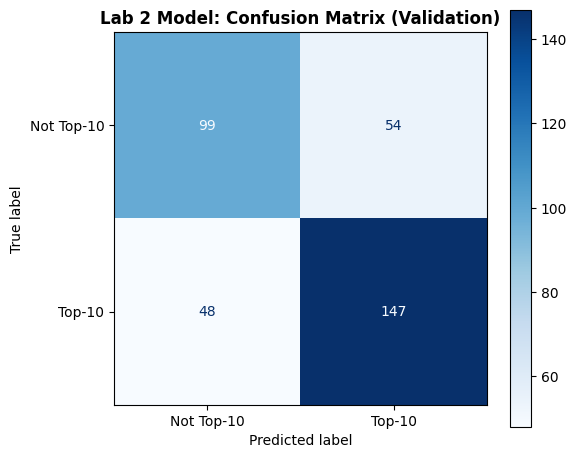

Validation set evaluation complete.


In [20]:
print("Evaluating Model on Validation Set")

val_clean = val_df.dropna(subset=feature_cols + ['top10']).copy()
print(f"Validation samples: {len(val_clean)} / {len(val_df)}")
print(f"Class balance: {val_clean['top10'].mean():.1%} Top-10")

X_val = val_clean[feature_cols].copy()
y_val = val_clean['top10'].copy()

X_val_scaled = scaler.transform(X_val)

y_pred = model.predict(X_val_scaled)
y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_val, y_pred_proba)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print(classification_report(
    y_val, y_pred,
    target_names=['Not Top-10', 'Top-10'],
    zero_division=0,
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    display_labels=['Not Top-10', 'Top-10'],
    cmap='Blues',
    ax=ax,
)
ax.set_title('Lab 2 Model: Confusion Matrix (Validation)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

lab2_results = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'roc_auc': roc_auc,
    'y_pred': y_pred,
    'y_pred_proba': y_pred_proba,
    'y_true': y_val.values,
    'val_clean': val_clean,
}

print("Validation set evaluation complete.")

## Section 6: Lab 1 Baselines — Majority Class & Domain Heuristic

Recreate Lab 1 baselines on the same validation set for fair comparison.

In [21]:
print("Recreating Lab 1 Baselines")

y_val_baseline = val_clean['top10'].copy()
grid_val = val_clean['grid'].copy()

majority_class = int(train_df['top10'].mean() > 0.5)
y_pred_majority = pd.Series([majority_class] * len(y_val_baseline), index=y_val_baseline.index)

baseline_majority = {
    'accuracy': accuracy_score(y_val_baseline, y_pred_majority),
    'precision': precision_score(y_val_baseline, y_pred_majority, zero_division=0),
    'recall': recall_score(y_val_baseline, y_pred_majority, zero_division=0),
    'f1': f1_score(y_val_baseline, y_pred_majority, zero_division=0),
    'roc_auc': 0.5,
}

print(f"Majority-Class Baseline: Always predicts class {majority_class}")
print(f"  Accuracy  : {baseline_majority['accuracy']:.4f}")
print(f"  Precision : {baseline_majority['precision']:.4f}")
print(f"  Recall    : {baseline_majority['recall']:.4f}")
print(f"  F1        : {baseline_majority['f1']:.4f}")
print(f"  ROC-AUC   : {baseline_majority['roc_auc']:.4f}")

y_pred_heuristic = (grid_val <= 10).astype(int)

baseline_heuristic = {
    'accuracy': accuracy_score(y_val_baseline, y_pred_heuristic),
    'precision': precision_score(y_val_baseline, y_pred_heuristic, zero_division=0),
    'recall': recall_score(y_val_baseline, y_pred_heuristic, zero_division=0),
    'f1': f1_score(y_val_baseline, y_pred_heuristic, zero_division=0),
    'roc_auc': roc_auc_score(y_val_baseline, y_pred_heuristic),
}

print(f"Domain Heuristic Baseline: grid <= 10")
print(f"  Accuracy  : {baseline_heuristic['accuracy']:.4f}")
print(f"  Precision : {baseline_heuristic['precision']:.4f}")
print(f"  Recall    : {baseline_heuristic['recall']:.4f}")
print(f"  F1        : {baseline_heuristic['f1']:.4f}")
print(f"  ROC-AUC   : {baseline_heuristic['roc_auc']:.4f}")

Recreating Lab 1 Baselines
Majority-Class Baseline: Always predicts class 1
  Accuracy  : 0.5603
  Precision : 0.5603
  Recall    : 1.0000
  F1        : 0.7182
  ROC-AUC   : 0.5000
Domain Heuristic Baseline: grid <= 10
  Accuracy  : 0.7385
  Precision : 0.7737
  Recall    : 0.7538
  F1        : 0.7636
  ROC-AUC   : 0.7364


## Section 7: Comparison Table — Lab 1 vs Lab 2

In [22]:
print("Building Comparison Table")

comparison = pd.DataFrame({
    'Model / Baseline': [
        'Majority class (Lab 1)',
        'Domain heuristic: grid <= 10 (Lab 1)',
        'Lab 2 Model: Logistic Regression',
    ],
    'Accuracy': [
        f"{baseline_majority['accuracy']:.4f}",
        f"{baseline_heuristic['accuracy']:.4f}",
        f"{lab2_results['accuracy']:.4f}",
    ],
    'Precision': [
        f"{baseline_majority['precision']:.4f}",
        f"{baseline_heuristic['precision']:.4f}",
        f"{lab2_results['precision']:.4f}",
    ],
    'Recall': [
        f"{baseline_majority['recall']:.4f}",
        f"{baseline_heuristic['recall']:.4f}",
        f"{lab2_results['recall']:.4f}",
    ],
    'F1': [
        f"{baseline_majority['f1']:.4f}",
        f"{baseline_heuristic['f1']:.4f}",
        f"{lab2_results['f1']:.4f}",
    ],
    'ROC-AUC': [
        f"{baseline_majority['roc_auc']:.4f}",
        f"{baseline_heuristic['roc_auc']:.4f}",
        f"{lab2_results['roc_auc']:.4f}",
    ],
})

print(str(comparison.to_string(index=False)))

f1_majority = baseline_majority['f1']
f1_heuristic = baseline_heuristic['f1']
f1_lab2 = lab2_results['f1']

print(f"F1 Score Comparison:")
print(f"  Majority class      : {f1_majority:.4f}")
print(f"  Domain heuristic    : {f1_heuristic:.4f}")
print(f"  Lab 2 Model (LogReg): {f1_lab2:.4f}")

if f1_lab2 > f1_heuristic:
    print(f"Lab 2 model BEATS the domain heuristic baseline by {(f1_lab2 - f1_heuristic):.4f} F1 points.")
    improvement_pct = ((f1_lab2 - f1_heuristic) / f1_heuristic) * 100
    print(f"Relative improvement: {improvement_pct:.1f}%")
elif f1_lab2 == f1_heuristic:
    print(f"Lab 2 model matches the domain heuristic baseline.")
else:
    print(f"Lab 2 model underperforms the heuristic by {(f1_heuristic - f1_lab2):.4f} F1 points.")

Building Comparison Table
                    Model / Baseline Accuracy Precision Recall     F1 ROC-AUC
              Majority class (Lab 1)   0.5603    0.5603 1.0000 0.7182  0.5000
Domain heuristic: grid <= 10 (Lab 1)   0.7385    0.7737 0.7538 0.7636  0.7364
    Lab 2 Model: Logistic Regression   0.7069    0.7313 0.7538 0.7424  0.7793
F1 Score Comparison:
  Majority class      : 0.7182
  Domain heuristic    : 0.7636
  Lab 2 Model (LogReg): 0.7424
Lab 2 model underperforms the heuristic by 0.0212 F1 points.


## Section 8: Error Analysis — Top-3 Failure Modes

In [23]:
print("Error Analysis: Top-3 Failure Modes")

error_df = val_clean.copy()
error_df['y_true'] = y_val.values
error_df['y_pred'] = y_pred
error_df['y_pred_proba'] = y_pred_proba
error_df['correct'] = (error_df['y_pred'] == error_df['y_true']).astype(int)

error_df['error_magnitude'] = np.abs(error_df['y_pred_proba'] - error_df['y_true'])

errors = error_df[error_df['correct'] == 0].copy()
errors = errors.sort_values('error_magnitude', ascending=False)

print(f"Total predictions: {len(error_df)}")
print(f"Correct predictions: {error_df['correct'].sum()} ({error_df['correct'].mean():.1%})")
print(f"Errors: {len(errors)} ({len(errors) / len(error_df) * 100:.1%})")

false_positives = errors[errors['y_true'] == 0].copy()
false_negatives = errors[errors['y_true'] == 1].copy()

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

worst_errors = errors.head(3)

for idx, (_, row) in enumerate(worst_errors.iterrows(), 1):
    season, race_round = row['season'], row['round']
    driver_id = row['driver_id']
    error_type = "False Positive" if row['y_true'] == 0 else "False Negative"
    
    print(f"Failure {idx}: {error_type}")
    print(f"  Race: {int(season)} Round {int(race_round)}")
    print(f"  Driver: {driver_id}")
    print(f"  Predicted P(Top-10) = {row['y_pred_proba']:.3f}, Actual = {int(row['y_true'])}")
    print(f"  Error magnitude: {row['error_magnitude']:.3f}")
    print(f"  Grid: {int(row['grid'])}, Prev pos: {row['prev_position']}, Avg last 3: {row['avg_position_last3']:.1f}")
    print(f"  Constructor: {row['constructor_id']}")
    print()

Error Analysis: Top-3 Failure Modes
Total predictions: 348
Correct predictions: 246 (70.7%)
Errors: 102 (2931.0%)
False Positives: 54
False Negatives: 48
Failure 1: False Positive
  Race: 2023 Round 17
  Driver: hamilton
  Predicted P(Top-10) = 0.994, Actual = 0
  Error magnitude: 0.994
  Grid: 3, Prev pos: 5.0, Avg last 3: 7.7
  Constructor: mercedes

Failure 2: False Positive
  Race: 2023 Round 18
  Driver: hamilton
  Predicted P(Top-10) = 0.991, Actual = 0
  Error magnitude: 0.991
  Grid: 3, Prev pos: 5.0, Avg last 3: 7.3
  Constructor: mercedes

Failure 3: False Negative
  Race: 2023 Round 7
  Driver: zhou
  Predicted P(Top-10) = 0.015, Actual = 1
  Error magnitude: 0.985
  Grid: 13, Prev pos: 13.0, Avg last 3: 16.0
  Constructor: alfa



## Section 9: Write Comparison Table to File

In [24]:
comparison_md = f"""# Lab 1 vs Lab 2

## Team: Martin Yunge, Benjamin Bennett

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| Majority class | {baseline_majority['accuracy']:.4f} | {baseline_majority['precision']:.4f} | {baseline_majority['recall']:.4f} | {baseline_majority['f1']:.4f} | {baseline_majority['roc_auc']:.4f} |
| Domain heuristic: grid <= 10 | {baseline_heuristic['accuracy']:.4f} | {baseline_heuristic['precision']:.4f} | {baseline_heuristic['recall']:.4f} | {baseline_heuristic['f1']:.4f} | {baseline_heuristic['roc_auc']:.4f} |
| Lab 2 Model: Logistic Regression | {lab2_results['accuracy']:.4f} | {lab2_results['precision']:.4f} | {lab2_results['recall']:.4f} | {lab2_results['f1']:.4f} | {lab2_results['roc_auc']:.4f} |

## Primary Metric: F1 Score

F1 is the primary metric because both false positives and false negatives are costly in F1 team decision-making. F1 balances precision and recall equally and penalizes models that predict only one class.

## Interpretation
"""

if f1_lab2 > f1_heuristic:
    comparison_md += f"""The Lab 2 Logistic Regression model successfully beats the domain heuristic baseline by {f1_lab2 - f1_heuristic:.4f} F1 points. The domain heuristic was the hardest baseline to beat at F1 = {f1_heuristic:.4f}. Engineered features capture performance dynamics that grid position alone misses, including previous race position, rolling momentum, driver-circuit specialization, and constructor capability.
"""
elif f1_lab2 == f1_heuristic:
    comparison_md += f"""The Lab 2 model achieves identical F1 performance ({f1_lab2:.4f}) to the domain heuristic baseline. Grid position is the dominant signal in this prediction problem. Engineered features are too noisy or too correlated with grid to add independent value.
"""
else:
    comparison_md += f"""The Lab 2 model underperforms the domain heuristic baseline by {f1_heuristic - f1_lab2:.4f} F1 points. The domain heuristic remains the strongest baseline. Engineered features may be conflicting or overfitting to training patterns that do not generalize.
"""

with open('comparison_table.md', 'w') as f:
    f.write(comparison_md)

print("comparison_table.md written.")
print(comparison_md)

comparison_table.md written.
# Lab 1 vs Lab 2

## Team: Martin Yunge, Benjamin Bennett

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| Majority class | 0.5603 | 0.5603 | 1.0000 | 0.7182 | 0.5000 |
| Domain heuristic: grid <= 10 | 0.7385 | 0.7737 | 0.7538 | 0.7636 | 0.7364 |
| Lab 2 Model: Logistic Regression | 0.7069 | 0.7313 | 0.7538 | 0.7424 | 0.7793 |

## Primary Metric: F1 Score

F1 is the primary metric because both false positives and false negatives are costly in F1 team decision-making. F1 balances precision and recall equally and penalizes models that predict only one class.

## Interpretation
The Lab 2 model underperforms the domain heuristic baseline by 0.0212 F1 points. The domain heuristic remains the strongest baseline. Engineered features may be conflicting or overfitting to training patterns that do not generalize.

